<a href="https://colab.research.google.com/github/PuttyChan/Chubu_lecture_room/blob/main/%E3%83%8F%E3%83%95%E5%A4%89%E6%8F%9B%E3%81%AE%E4%BE%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## `hough_line_transform`関数の実装

In [15]:
def hough_line_transform(edges, theta_step=1, threshold=100, neighborhood_size=20):
    height, width = edges.shape
    max_rho = int(np.sqrt(height**2 + width**2))
    rho_range = np.arange(-max_rho, max_rho + 1)
    theta_range = np.deg2rad(np.arange(0, 180, theta_step))

    accumulator = np.zeros((len(rho_range), len(theta_range)), dtype=np.int32)
    y_coords, x_coords = np.where(edges != 0)

    # 最適化: ラジアンの計算を事前に行う
    cos_t = np.cos(theta_range)
    sin_t = np.sin(theta_range)

    for i in range(len(x_coords)):
        x, y = x_coords[i], y_coords[i]
        # すべての角度に対してrhoを一括計算
        rhos = x * cos_t + y * sin_t
        # 各rhoに対応するインデックスを計算
        rho_idxs = np.round(rhos + max_rho).astype(int)

        for t_idx, r_idx in enumerate(rho_idxs):
            if 0 <= r_idx < len(rho_range):
                accumulator[r_idx, t_idx] += 1

    # 非最大値抑制 (NMS): 近傍の中で最大値のものだけを抽出
    lines = []
    candidate_indices = np.argwhere(accumulator >= threshold)

    # 投票数が多い順にソート
    candidate_indices = candidate_indices[accumulator[candidate_indices[:,0], candidate_indices[:,1]].argsort()[::-1]]

    processed_accumulator = accumulator.copy()
    for r_idx, t_idx in candidate_indices:
        if processed_accumulator[r_idx, t_idx] >= threshold:
            rho = rho_range[r_idx]
            theta = theta_range[t_idx]
            lines.append((rho, theta))

            # 採用した点の近傍を抑制する
            r_start = max(0, r_idx - neighborhood_size)
            r_end = min(len(rho_range), r_idx + neighborhood_size + 1)
            t_start = max(0, t_idx - neighborhood_size)
            t_end = min(len(theta_range), t_idx + neighborhood_size + 1)
            processed_accumulator[r_start:r_end, t_start:t_end] = 0

    return lines, accumulator

検出された直線候補数: 14


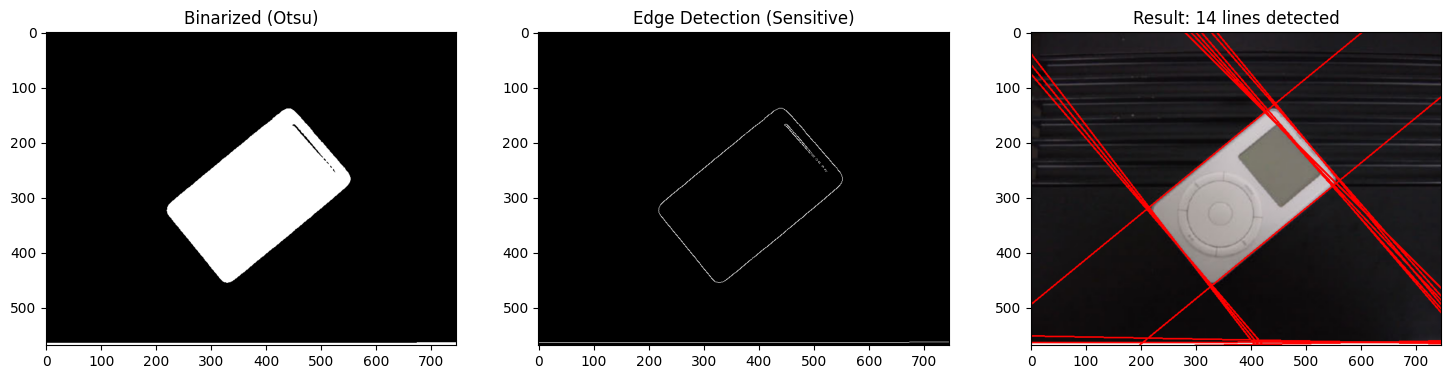

In [20]:
# 精度向上版: エラー修正と感度の最大化
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

if 'image_path' not in locals():
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1. 前処理
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 2. 二値化（大津）
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. エッジ抽出: しきい値を下げて連続性を重視
edges = cv2.Canny(binary, threshold1=30, threshold2=100)

# 4. 自作ハフ変換
lines, accumulator = hough_line_transform(edges, theta_step=0.5, threshold=50, neighborhood_size=10)

print('検出された直線候補数:', len(lines))

result = image_rgb.copy()
for rho, theta in lines[:50]: # 上位50本まで表示
    a, b = np.cos(theta), np.sin(theta)
    x0, y0 = a * rho, b * rho
    x1, y1 = int(x0 + 2000 * (-b)), int(y0 + 2000 * (a))
    x2, y2 = int(x0 - 2000 * (-b)), int(y0 - 2000 * (a))
    # 第3引数に終点 (x2, y2) を追加して修正
    cv2.line(result, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(binary, cmap='gray')
plt.title('Binarized (Otsu)')
plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection (Sensitive)')
plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title(f'Result: {len(lines)} lines detected')
plt.show()